In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

In [2]:
dataset = pd.read_csv("diabetes.csv")
dataset.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [3]:
dataset.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

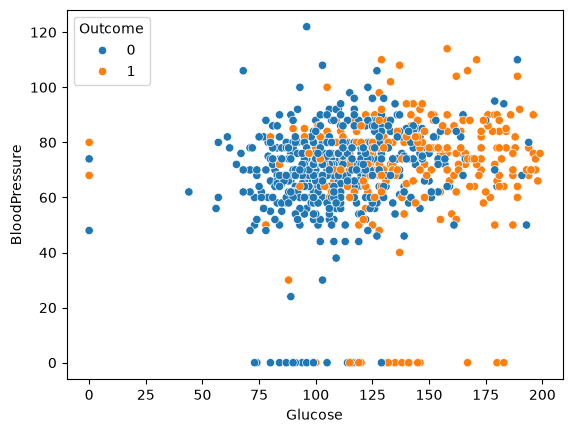

In [4]:
#dataset.drop(columns=["Student_ID"],inplace=True)
sns.scatterplot(x="Glucose",y="BloodPressure", data=dataset, hue="Outcome")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
x= dataset.iloc[:,:-1]
y = dataset["Outcome"]
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)


In [6]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train , y_train)
lr.score(x_test,y_test)*100

C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


74.67532467532467

In [8]:
# from mlxtend.plotting import plot_decision_regions
# plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=lr)
# plt.show()

# For two features

C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


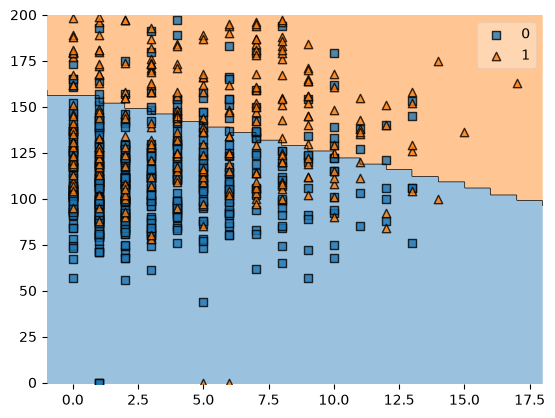

In [9]:
# Solution 1 (Recommended): Select Only 2 Features
x_new = x.iloc[:, :2]   # First two columns

lr.fit(x_new, y)

plot_decision_regions(
    X=x_new.to_numpy(),
    y=y.to_numpy(),
    clf=lr
)

plt.show()

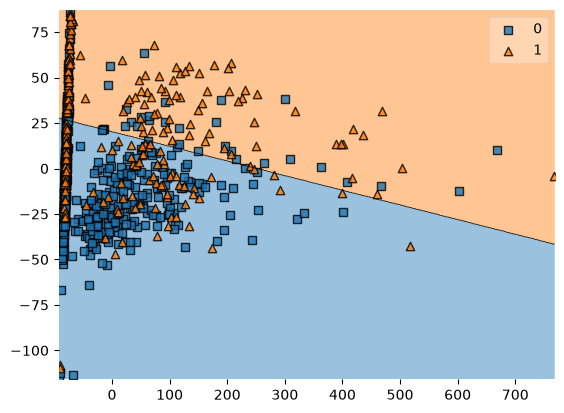

In [10]:
# Solution 2: Use PCA
# If you want to visualize all features together:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions

pca = PCA(n_components=2)

x_pca = pca.fit_transform(x)

lr = LogisticRegression()
lr.fit(x_pca, y)

plot_decision_regions(
    X=x_pca,
    y=y.to_numpy(),
    clf=lr
)

plt.show()